In [3]:
import os
os.listdir()

['.config',
 'tech-weekend-data-science-hackathon.zip',
 'test.csv',
 'train.csv',
 'sample_submission.csv',
 'sample_data']

In [4]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
train.head()

(600000, 15)


,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# информация о данных
print(train.info())

# пропуски
print("\nMissing values:\n", train.isnull().sum())

# статистика
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


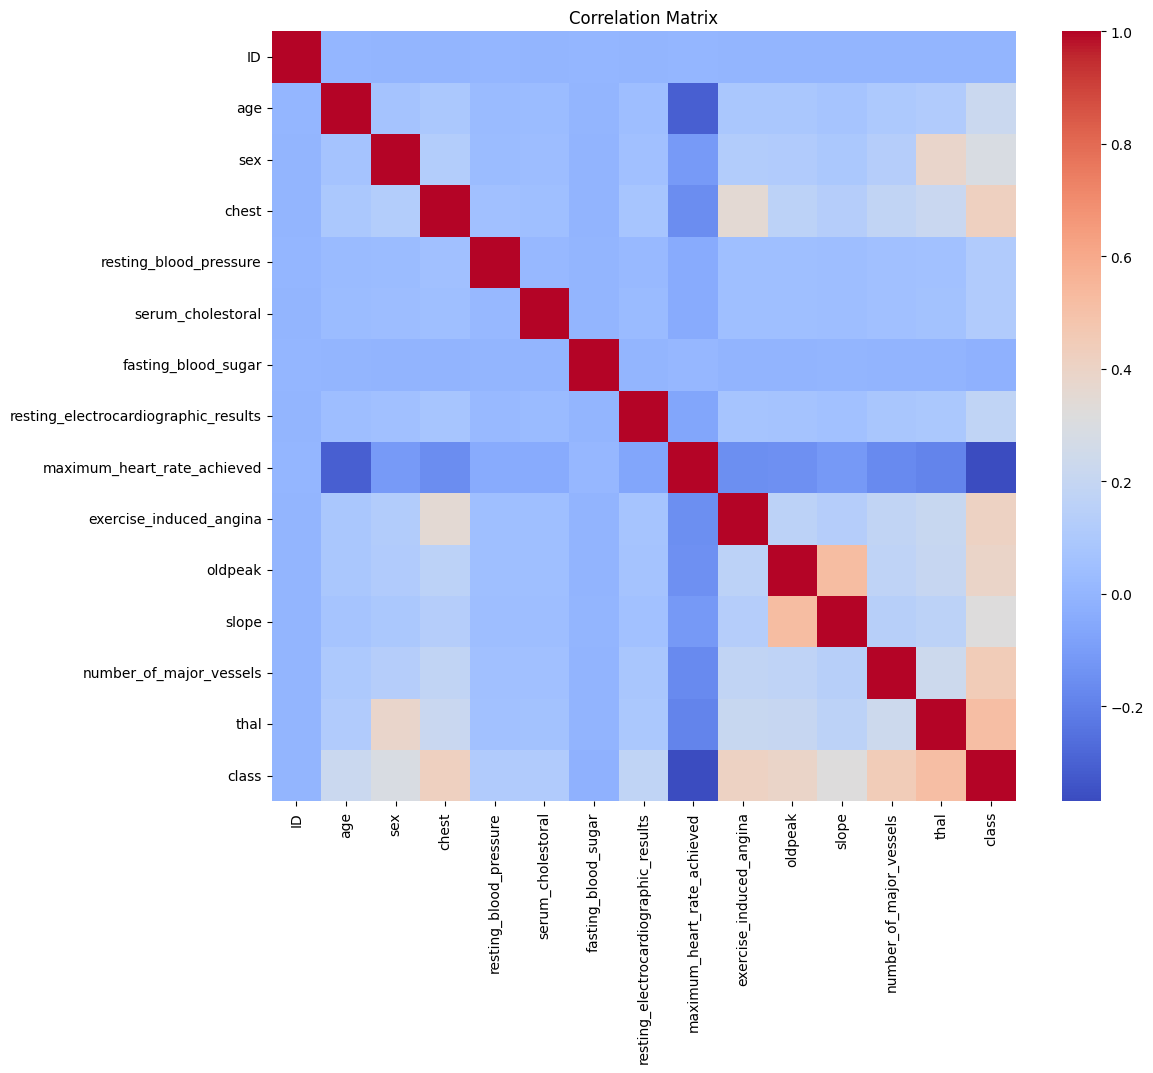

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

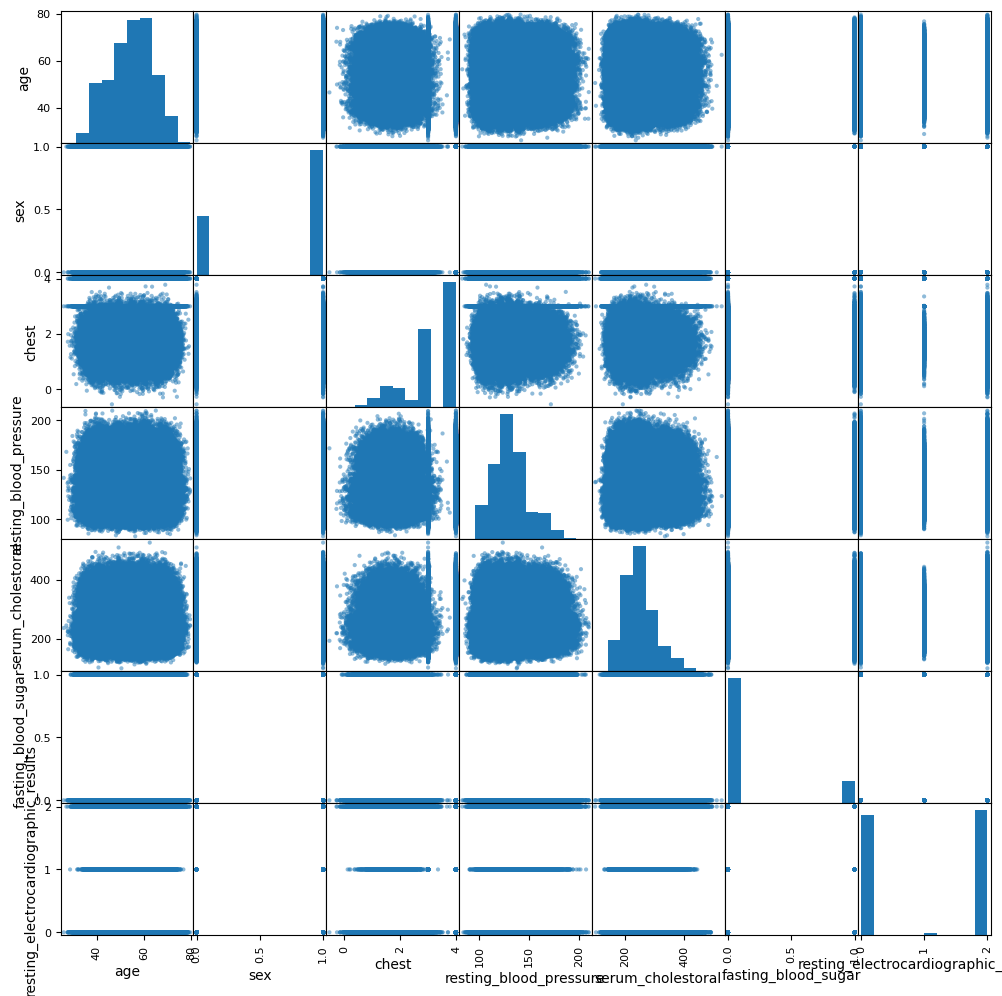

In [7]:
from pandas.plotting import scatter_matrix

scatter_matrix(train.iloc[:, 1:8], figsize=(12, 12))
plt.show()

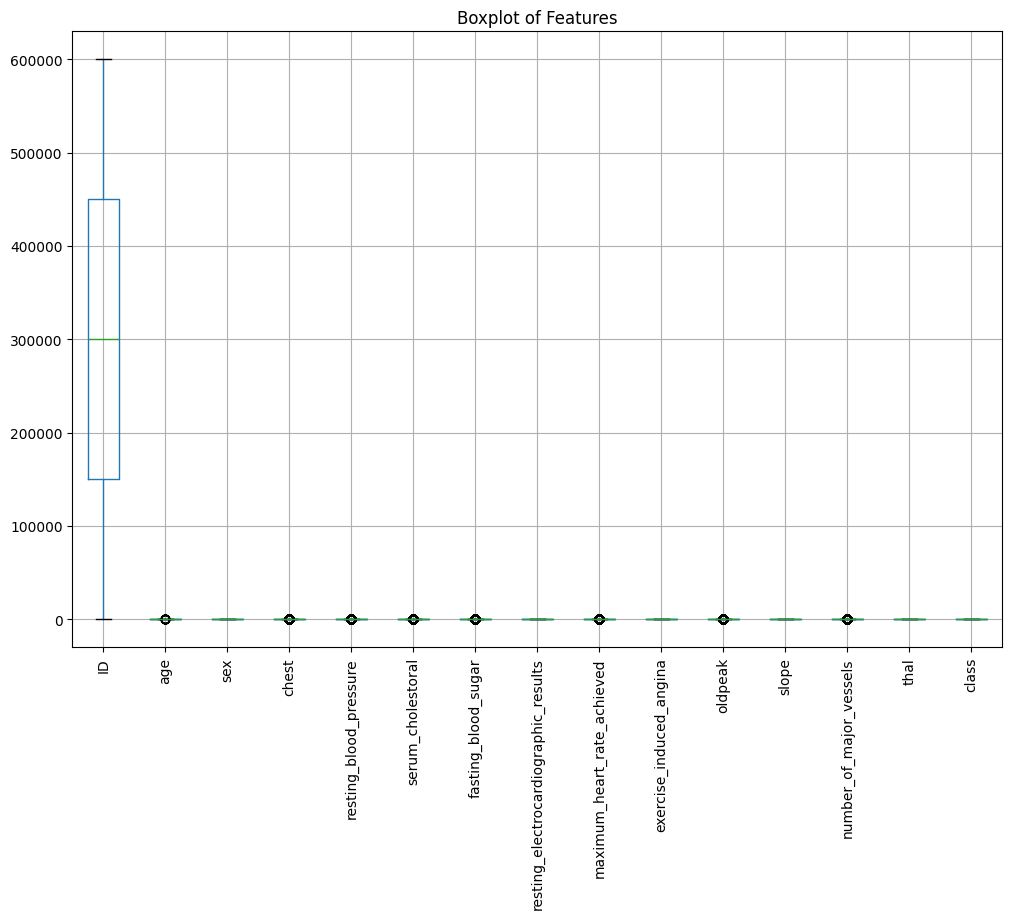

In [8]:
plt.figure(figsize=(12, 8))
train.boxplot(rot=90)
plt.title("Boxplot of Features")
plt.show()

In [9]:
train_sample = train.sample(5000, random_state=42)

In [10]:
train.columns

Index(['ID', 'age', 'sex', 'chest', 'resting_blood_pressure',
       'serum_cholestoral', 'fasting_blood_sugar',
       'resting_electrocardiographic_results', 'maximum_heart_rate_achieved',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'number_of_major_vessels', 'thal', 'class'],
      dtype='object')

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# удаляем ID
train = train.drop(columns=['ID'])

# разделяем признаки и target
X = train.drop(columns=['class'])
y = train['class']

# делим на train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_val.shape)

(480000, 13) (120000, 13)


In [12]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: Index(['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral',
       'fasting_blood_sugar', 'resting_electrocardiographic_results',
       'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak',
       'slope', 'number_of_major_vessels', 'thal'],
      dtype='object')
Categorical: Index([], dtype='object')


In [13]:
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_val)
y_proba = logreg_model.predict_proba(X_val)[:, 1]

In [15]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("LogReg Accuracy:", accuracy_score(y_val, y_pred))
print("LogReg F1:", f1_score(y_val, y_pred))
print("LogReg ROC-AUC:", roc_auc_score(y_val, y_proba))

LogReg Accuracy: 0.8788083333333333
LogReg F1: 0.8620771412042525
LogReg ROC-AUC: 0.9482691259006057


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("RF Accuracy:", accuracy_score(y_val, y_pred_rf))
print("RF F1:", f1_score(y_val, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_val, y_proba_rf))

RF Accuracy: 0.8969833333333334
RF F1: 0.8829422570687272
RF ROC-AUC: 0.9600546010888297


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("RF Accuracy:", accuracy_score(y_val, y_pred_rf))
print("RF F1:", f1_score(y_val, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_val, y_proba_rf))

RF Accuracy: 0.8969833333333334
RF F1: 0.8829422570687272
RF ROC-AUC: 0.9600546010888297


In [21]:
# подвыборка для нейросети
X_train_nn = X_train.sample(120000, random_state=42)
y_train_nn = y_train.loc[X_train_nn.index]

X_val_nn = X_val.copy()
y_val_nn = y_val.copy()

# обучаем препроцессор и трансформируем данные
X_train_nn_processed = preprocessor.fit_transform(X_train_nn)
X_val_nn_processed = preprocessor.transform(X_val_nn)

print(X_train_nn_processed.shape)
print(X_val_nn_processed.shape)

(120000, 13)
(120000, 13)


In [22]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# если sparse matrix -> в dense
X_train_nn_processed = X_train_nn_processed.toarray() if hasattr(X_train_nn_processed, "toarray") else X_train_nn_processed
X_val_nn_processed = X_val_nn_processed.toarray() if hasattr(X_val_nn_processed, "toarray") else X_val_nn_processed

X_train_tensor = torch.tensor(X_train_nn_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_nn.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_nn_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_nn.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [23]:
X_train_nn = X_train.sample(60000, random_state=42)
y_train_nn = y_train.loc[X_train_nn.index]

In [24]:
class HeartDiseaseNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_tensor.shape[1]
model = HeartDiseaseNN(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [25]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

num_epochs = 10

train_losses = []
val_losses = []
val_aucs = []

best_val_auc = 0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item()

            probs_batch = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs_batch)
            all_targets.extend(y_batch.cpu().numpy().flatten())

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_auc = roc_auc_score(all_targets, all_probs)
    val_aucs.append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = model.state_dict()

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val ROC-AUC: {val_auc:.4f}")

Epoch 1/10 | Train Loss: 0.3517 | Val Loss: 0.2789 | Val ROC-AUC: 0.9519
Epoch 2/10 | Train Loss: 0.2797 | Val Loss: 0.2691 | Val ROC-AUC: 0.9550
Epoch 3/10 | Train Loss: 0.2729 | Val Loss: 0.2642 | Val ROC-AUC: 0.9566
Epoch 4/10 | Train Loss: 0.2686 | Val Loss: 0.2618 | Val ROC-AUC: 0.9574
Epoch 5/10 | Train Loss: 0.2664 | Val Loss: 0.2607 | Val ROC-AUC: 0.9577
Epoch 6/10 | Train Loss: 0.2660 | Val Loss: 0.2607 | Val ROC-AUC: 0.9579
Epoch 7/10 | Train Loss: 0.2634 | Val Loss: 0.2596 | Val ROC-AUC: 0.9581
Epoch 8/10 | Train Loss: 0.2634 | Val Loss: 0.2584 | Val ROC-AUC: 0.9585
Epoch 9/10 | Train Loss: 0.2619 | Val Loss: 0.2580 | Val ROC-AUC: 0.9587
Epoch 10/10 | Train Loss: 0.2599 | Val Loss: 0.2572 | Val ROC-AUC: 0.9588


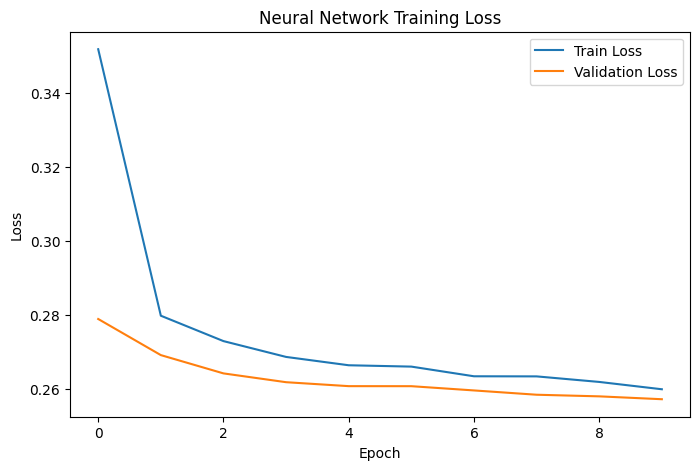

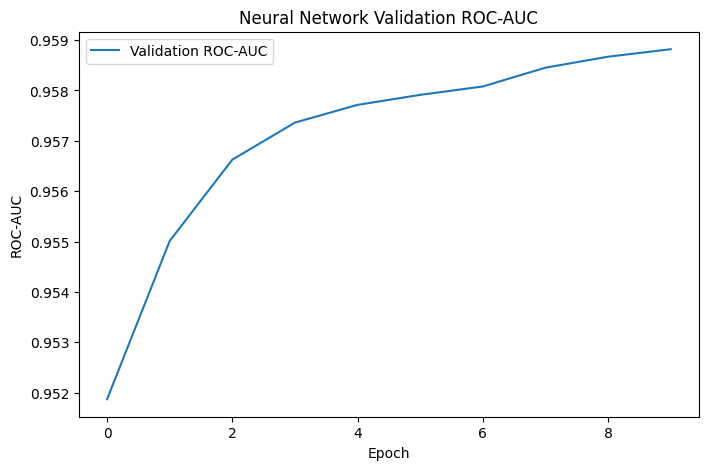

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(val_aucs, label='Validation ROC-AUC')
plt.title('Neural Network Validation ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.legend()
plt.show()

In [27]:
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    logits = model(X_val_tensor.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().flatten()
    preds = (probs >= 0.5).astype(int)

print("NN Accuracy:", accuracy_score(y_val_nn, preds))
print("NN F1:", f1_score(y_val_nn, preds))
print("NN ROC-AUC:", roc_auc_score(y_val_nn, probs))

NN Accuracy: 0.8940416666666666
NN F1: 0.8789981062228186
NN ROC-AUC: 0.9588183572388194


In [28]:
import os
import joblib

os.makedirs("models", exist_ok=True)

torch.save(best_model_state, "models/best_nn.pt")
joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(logreg_model, "models/best_logreg.pkl")
joblib.dump(rf_model, "models/best_random_forest.pkl")

print("Models saved successfully")

Models saved successfully


In [29]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_val, y_pred),
        accuracy_score(y_val, y_pred_rf),
        accuracy_score(y_val_nn, preds)
    ],
    "F1": [
        f1_score(y_val, y_pred),
        f1_score(y_val, y_pred_rf),
        f1_score(y_val_nn, preds)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_proba),
        roc_auc_score(y_val, y_proba_rf),
        roc_auc_score(y_val_nn, probs)
    ]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,F1,ROC-AUC
1,Random Forest,0.896983,0.882942,0.960055
2,Neural Network,0.894042,0.878998,0.958818
0,Logistic Regression,0.878808,0.862077,0.948269
